In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score
from kmodes.kprototypes import KPrototypes
import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_parquet(
    r"C:\Users\lucyq\Dropbox\AMDP\THESIS\012_data_cluster_ready.parquet").copy()
print('Number of accidents: ', df.shape[0],
      '\nNumber of variables:', df.shape[1], '\n')
df.info()

Number of accidents:  14849 
Number of variables: 36 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14849 entries, 0 to 14848
Data columns (total 36 columns):
 #   Column                        Non-Null Count  Dtype                      
---  ------                        --------------  -----                      
 0   Protocollo                    14849 non-null  int64                      
 1   total_injury_severity         14849 non-null  int32                      
 2   max_injury_severity           14849 non-null  int32                      
 3   num_pedestrians_hit           14849 non-null  int64                      
 4   num_male                      14849 non-null  int32                      
 5   num_female                    14849 non-null  int32                      
 6   num_unknown_gender            14849 non-null  int32                      
 7   multiple_pedestrians          14849 non-null  int32                      
 8   severity_winsorized           14849 non-n

K-PROTOTYPES DAY GROUPING COMPARISON
Testing: Pairs vs 3-Way vs Binary

✓ All DAY groupings created

Running K-Prototypes with k=7, γ=1.5
Testing stability across 5 random seeds


Testing: Pairs (Mon/TW/TF/SS)

✓ Preprocessing complete:
  Shape: (14849, 16)
  Categorical features: 10
  Numerical features: 6
  dtype: float32
Shape: (14849, 16) (10 categorical, 6 numerical)
  Seed 42... Cost: 105172.94, Iter: 16
  Seed 43... Cost: 107299.70, Iter: 43
  Seed 44... Cost: 106069.59, Iter: 20
  Seed 45... Cost: 104536.69, Iter: 22
  Seed 46... Cost: 104006.14, Iter: 8

  METRICS:
    Cost: 104006.14 (±1165.80)
    Silhouette: 0.1969
    Calinski-Harabasz: 3144.18
    Davies-Bouldin: 1.4324
    Stability (ARI): 0.5579
    Size ratio: 6.41

Testing: 3-Way (Wknd/F/MTWT)

✓ Preprocessing complete:
  Shape: (14849, 16)
  Categorical features: 10
  Numerical features: 6
  dtype: float32
Shape: (14849, 16) (10 categorical, 6 numerical)
  Seed 42... Cost: 97476.05, Iter: 9
  Seed 43... Cost: 101738.

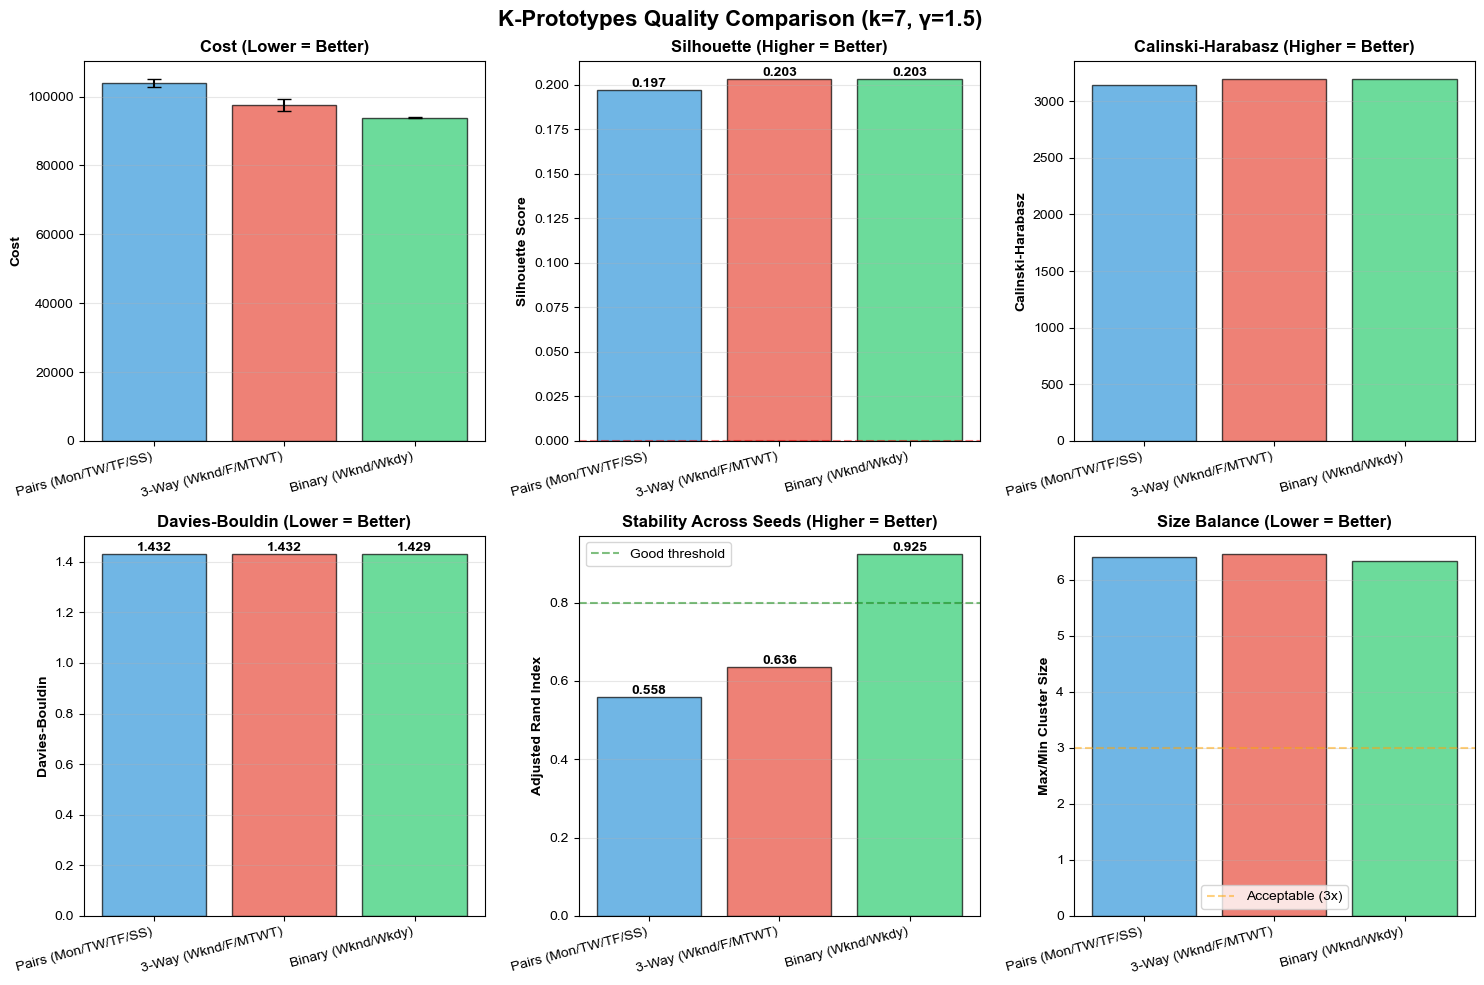


LIFT ANALYSIS - DAY Feature Distinctiveness by Cluster

Pairs (Mon/TW/TF/SS) - DAY Lift by Cluster

Lift Matrix (values >1.5 indicate strong association):
         Cluster 0  Cluster 1  Cluster 2  Cluster 3  Cluster 4  Cluster 5  Cluster 6
Monday        0.99       0.88       1.73       1.12       0.98       0.94       1.02
Tue+Wed       1.21       0.77       0.88       1.12       0.80       1.20       0.94
Thu+Fri       0.78       1.21       0.81       0.81       1.28       0.85       1.10
Sat+Sun       1.01       1.16       0.92       1.01       0.90       0.94       0.91

Average maximum lift: 1.34
(Higher = DAY feature creates more distinct cluster profiles)

3-Way (Wknd/F/MTWT) - DAY Lift by Cluster

Lift Matrix (values >1.5 indicate strong association):
         Cluster 0  Cluster 1  Cluster 2  Cluster 3  Cluster 4  Cluster 5  Cluster 6
Midweek       1.00       1.01       0.99       1.03       1.04       0.96       1.04
Friday        1.12       1.03       1.03       1.00       0.

In [6]:
# Set clean font
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']

print("="*70)
print("K-PROTOTYPES DAY GROUPING COMPARISON")
print("Testing: Pairs vs 3-Way vs Binary")
print("="*70)

# ============================================================
# PART 1: SETUP - Create all three DAY versions
# ============================================================

# Ensure all DAY groupings exist
if 'day_pairs' not in df.columns:
    def classify_day_pairs(day):
        if day == 1:
            return 0  # Monday
        elif day in [2, 3]:
            return 1  # Tue+Wed
        elif day in [4, 5]:
            return 2  # Thu+Fri
        else:  # 6, 7
            return 3  # Sat+Sun
    df['day_pairs'] = df['DAY'].apply(classify_day_pairs)

if 'day_3way' not in df.columns:
    def classify_day_3way(day):
        if day in [6, 7]:
            return 2  # Weekend
        elif day == 5:
            return 1  # Friday
        else:
            return 0  # Midweek (Mon-Thu)
    df['day_3way'] = df['DAY'].apply(classify_day_3way)

if 'day_weekend_binary' not in df.columns:
    df['day_weekend_binary'] = (df['DAY'].isin([6, 7])).astype(int)

print("\n✓ All DAY groupings created")

# ============================================================
# PART 2: PREPROCESSING FUNCTION
# ============================================================


def preprocess_data(df, categorical_cols, numerical_cols):
    """
    Efficient preprocessing for K-Prototypes:
    - Categoricals: OrdinalEncoder → int32
    - Numericals: StandardScaler → float32
    """
    # Categorical encoding
    df_cat = df[categorical_cols].copy()
    df_cat = df_cat.astype("object").fillna("(missing)")

    enc = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)
    X_cat = enc.fit_transform(df_cat)
    X_cat = np.where(np.isnan(X_cat), -1, X_cat)
    X_cat = X_cat.astype(np.int32, copy=False)

    # Create category mappings for later interpretation
    cat_maps = {col: {cat: i for i, cat in enumerate(enc.categories_[j])}
                for j, col in enumerate(categorical_cols)}
    rev_maps = {col: {i: cat for i, cat in enumerate(enc.categories_[j])}
                for j, col in enumerate(categorical_cols)}
    for col in categorical_cols:
        rev_maps[col][-1] = None

    # Numerical standardization
    X_num = df[numerical_cols].apply(pd.to_numeric, errors="coerce")
    num_medians = X_num.median(numeric_only=True)
    X_num = X_num.fillna(num_medians)

    scaler = StandardScaler()
    X_num_scaled = scaler.fit_transform(X_num).astype(np.float32, copy=False)

    # Combine: categoricals FIRST (critical for K-Prototypes)
    X = np.concatenate(
        [X_cat.astype(np.float32, copy=False), X_num_scaled], axis=1)
    categorical_indices = list(range(len(categorical_cols)))

    # Sanity checks
    assert X.dtype == np.float32, f"Expected float32, got {X.dtype}"
    assert np.isfinite(X).all(), "X contains NaN or inf values"

    print(f"\n✓ Preprocessing complete:")
    print(f"  Shape: {X.shape}")
    print(f"  Categorical features: {len(categorical_indices)}")
    print(f"  Numerical features: {len(numerical_cols)}")
    print(f"  dtype: {X.dtype}")

    return X, categorical_indices, enc, scaler, num_medians, rev_maps

# ============================================================
# PART 3: RUN K-PROTOTYPES FOR EACH DAY GROUPING
# ============================================================


# Base features (excluding DAY - we'll add the different versions)
base_categorical = [
    'multiple_pedestrians',
    'natural_light',
    'road_features',
    'TipoStradaDifficulty',
    'traffic_density',
    'vehicle_type',
    'road_conditions_bin',
    'weather_group',
    'driver_injury'
]

numerical_features = [
    'temperature_2m (°C)',
    'relative_humidity_2m (%)',
    'wind_gusts_10m (km/h)',
    'weather_days_since_last_rain',
    'male_proportion',
    'precipitation (mm)'
]

# Your chosen k and gamma from previous analysis
chosen_k = 7  # Update this to your chosen k
chosen_gamma = 1.5  # Update this to your chosen gamma
n_seeds = 5  # Number of random seeds for stability testing

day_versions = {
    'Pairs (Mon/TW/TF/SS)': 'day_pairs',
    '3-Way (Wknd/F/MTWT)': 'day_3way',
    'Binary (Wknd/Wkdy)': 'day_weekend_binary'
}

results = {}

print(f"\nRunning K-Prototypes with k={chosen_k}, γ={chosen_gamma}")
print(f"Testing stability across {n_seeds} random seeds\n")

for version_name, day_col in day_versions.items():
    print(f"\n{'='*70}")
    print(f"Testing: {version_name}")
    print(f"{'='*70}")

    # Prepare features with this DAY version
    categorical_cols = base_categorical + [day_col]

    # Preprocess
    X, cat_indices, enc, scaler, num_medians, rev_maps = preprocess_data(
        df, categorical_cols, numerical_features
    )

    print(
        f"Shape: {X.shape} ({len(cat_indices)} categorical, {len(numerical_features)} numerical)")

    # Storage for multiple runs
    costs = []
    labels_list = []
    n_iters = []

    # Run multiple times with different seeds for stability
    for seed in range(42, 42 + n_seeds):
        print(f"  Seed {seed}...", end=" ")

        kproto = KPrototypes(
            n_clusters=chosen_k,
            init="Cao",
            gamma=chosen_gamma,
            n_init=3,
            max_iter=100,
            random_state=seed,
            verbose=0
        )

        labels = kproto.fit_predict(X, categorical=cat_indices)

        costs.append(kproto.cost_)
        labels_list.append(labels)
        n_iters.append(kproto.n_iter_)

        print(f"Cost: {kproto.cost_:.2f}, Iter: {kproto.n_iter_}")

    # Use best run (lowest cost)
    best_idx = np.argmin(costs)
    best_labels = labels_list[best_idx]
    best_cost = costs[best_idx]

    # Calculate quality metrics (using numerical features only for standard metrics)
    n_cat = len(cat_indices)
    X_num = X[:, n_cat:]

    # Sample for silhouette (too slow on full dataset)
    sample_size = min(5000, X.shape[0])
    rng = np.random.RandomState(42)
    idx = rng.choice(X.shape[0], size=sample_size, replace=False)

    sil_score = silhouette_score(X_num[idx], best_labels[idx])
    ch_score = calinski_harabasz_score(X_num, best_labels)
    db_score = davies_bouldin_score(X_num, best_labels)

    # Calculate stability (Adjusted Rand Index between runs)
    ari_scores = []
    for i in range(len(labels_list)-1):
        ari = adjusted_rand_score(labels_list[i], labels_list[i+1])
        ari_scores.append(ari)
    avg_ari = np.mean(ari_scores)

    # Cluster size balance
    cluster_sizes = pd.Series(best_labels).value_counts().sort_index()
    size_ratio = cluster_sizes.max() / cluster_sizes.min()

    # Store results
    results[version_name] = {
        'labels': best_labels,
        'cost': best_cost,
        'cost_std': np.std(costs),
        'silhouette': sil_score,
        'calinski_harabasz': ch_score,
        'davies_bouldin': db_score,
        'stability_ari': avg_ari,
        'size_ratio': size_ratio,
        'cluster_sizes': cluster_sizes,
        'X': X,
        'cat_indices': cat_indices,
        'categorical_cols': categorical_cols,
        'n_iters_avg': np.mean(n_iters)
    }

    print(f"\n  METRICS:")
    print(f"    Cost: {best_cost:.2f} (±{np.std(costs):.2f})")
    print(f"    Silhouette: {sil_score:.4f}")
    print(f"    Calinski-Harabasz: {ch_score:.2f}")
    print(f"    Davies-Bouldin: {db_score:.4f}")
    print(f"    Stability (ARI): {avg_ari:.4f}")
    print(f"    Size ratio: {size_ratio:.2f}")

# ============================================================
# PART 4: COMPARE METRICS ACROSS VERSIONS
# ============================================================

print("\n" + "="*70)
print("COMPARISON SUMMARY")
print("="*70)

comparison_df = pd.DataFrame({
    'Version': list(results.keys()),
    'Cost': [r['cost'] for r in results.values()],
    'Cost_Std': [r['cost_std'] for r in results.values()],
    'Silhouette': [r['silhouette'] for r in results.values()],
    'Calinski_Harabasz': [r['calinski_harabasz'] for r in results.values()],
    'Davies_Bouldin': [r['davies_bouldin'] for r in results.values()],
    'Stability_ARI': [r['stability_ari'] for r in results.values()],
    'Size_Ratio': [r['size_ratio'] for r in results.values()],
    'Avg_Iterations': [r['n_iters_avg'] for r in results.values()]
})

print("\n" + comparison_df.to_string(index=False))

# Identify best performers
print("\n" + "="*70)
print("BEST PERFORMERS")
print("="*70)
print(
    f"Lowest Cost:          {comparison_df.loc[comparison_df['Cost'].idxmin(), 'Version']}")
print(
    f"Highest Silhouette:   {comparison_df.loc[comparison_df['Silhouette'].idxmax(), 'Version']}")
print(
    f"Highest CH:           {comparison_df.loc[comparison_df['Calinski_Harabasz'].idxmax(), 'Version']}")
print(
    f"Lowest DB:            {comparison_df.loc[comparison_df['Davies_Bouldin'].idxmin(), 'Version']}")
print(
    f"Most Stable (ARI):    {comparison_df.loc[comparison_df['Stability_ARI'].idxmax(), 'Version']}")
print(
    f"Best Size Balance:    {comparison_df.loc[comparison_df['Size_Ratio'].idxmin(), 'Version']}")

# ============================================================
# PART 5: VISUALIZE COMPARISON
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle(f'K-Prototypes Quality Comparison (k={chosen_k}, γ={chosen_gamma})',
             fontsize=16, fontweight='bold')

versions = list(results.keys())
colors = ['#3498db', '#e74c3c', '#2ecc71']

# Plot 1: Cost
ax = axes[0, 0]
costs = [results[v]['cost'] for v in versions]
cost_stds = [results[v]['cost_std'] for v in versions]
bars = ax.bar(range(len(versions)), costs, color=colors,
              alpha=0.7, edgecolor='black')
ax.errorbar(range(len(versions)), costs, yerr=cost_stds,
            fmt='none', color='black', capsize=5)
ax.set_xticks(range(len(versions)))
ax.set_xticklabels(versions, rotation=15, ha='right')
ax.set_ylabel('Cost', fontweight='bold')
ax.set_title('Cost (Lower = Better)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Plot 2: Silhouette Score
ax = axes[0, 1]
sil_scores = [results[v]['silhouette'] for v in versions]
bars = ax.bar(range(len(versions)), sil_scores,
              color=colors, alpha=0.7, edgecolor='black')
ax.set_xticks(range(len(versions)))
ax.set_xticklabels(versions, rotation=15, ha='right')
ax.set_ylabel('Silhouette Score', fontweight='bold')
ax.set_title('Silhouette (Higher = Better)', fontweight='bold')
ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, sil_scores)):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.3f}',
            ha='center', va='bottom', fontweight='bold')

# Plot 3: Calinski-Harabasz
ax = axes[0, 2]
ch_scores = [results[v]['calinski_harabasz'] for v in versions]
bars = ax.bar(range(len(versions)), ch_scores,
              color=colors, alpha=0.7, edgecolor='black')
ax.set_xticks(range(len(versions)))
ax.set_xticklabels(versions, rotation=15, ha='right')
ax.set_ylabel('Calinski-Harabasz', fontweight='bold')
ax.set_title('Calinski-Harabasz (Higher = Better)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Plot 4: Davies-Bouldin
ax = axes[1, 0]
db_scores = [results[v]['davies_bouldin'] for v in versions]
bars = ax.bar(range(len(versions)), db_scores,
              color=colors, alpha=0.7, edgecolor='black')
ax.set_xticks(range(len(versions)))
ax.set_xticklabels(versions, rotation=15, ha='right')
ax.set_ylabel('Davies-Bouldin', fontweight='bold')
ax.set_title('Davies-Bouldin (Lower = Better)', fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, db_scores)):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.3f}',
            ha='center', va='bottom', fontweight='bold')

# Plot 5: Stability (ARI)
ax = axes[1, 1]
ari_scores = [results[v]['stability_ari'] for v in versions]
bars = ax.bar(range(len(versions)), ari_scores,
              color=colors, alpha=0.7, edgecolor='black')
ax.set_xticks(range(len(versions)))
ax.set_xticklabels(versions, rotation=15, ha='right')
ax.set_ylabel('Adjusted Rand Index', fontweight='bold')
ax.set_title('Stability Across Seeds (Higher = Better)', fontweight='bold')
ax.axhline(y=0.8, color='green', linestyle='--',
           alpha=0.5, label='Good threshold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, ari_scores)):
    ax.text(bar.get_x() + bar.get_width()/2, val, f'{val:.3f}',
            ha='center', va='bottom', fontweight='bold')

# Plot 6: Cluster Size Balance
ax = axes[1, 2]
size_ratios = [results[v]['size_ratio'] for v in versions]
bars = ax.bar(range(len(versions)), size_ratios,
              color=colors, alpha=0.7, edgecolor='black')
ax.set_xticks(range(len(versions)))
ax.set_xticklabels(versions, rotation=15, ha='right')
ax.set_ylabel('Max/Min Cluster Size', fontweight='bold')
ax.set_title('Size Balance (Lower = Better)', fontweight='bold')
ax.axhline(y=3, color='orange', linestyle='--',
           alpha=0.5, label='Acceptable (3x)')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# PART 6: LIFT ANALYSIS FOR EACH VERSION
# ============================================================

print("\n" + "="*70)
print("LIFT ANALYSIS - DAY Feature Distinctiveness by Cluster")
print("="*70)


def calculate_day_lift(df, labels, day_col):
    """Calculate lift for DAY categories in each cluster"""
    df_temp = df.copy()
    df_temp['cluster'] = labels

    lifts_by_cluster = {}

    for cluster_id in sorted(df_temp['cluster'].unique()):
        cluster_data = df_temp[df_temp['cluster'] == cluster_id]

        # Day distribution in cluster vs overall
        cluster_day_dist = cluster_data[day_col].value_counts(normalize=True)
        overall_day_dist = df_temp[day_col].value_counts(normalize=True)

        lifts = {}
        for day_cat in overall_day_dist.index:
            cluster_prop = cluster_day_dist.get(day_cat, 0)
            overall_prop = overall_day_dist.get(day_cat, 0)
            if overall_prop > 0:
                lifts[day_cat] = cluster_prop / overall_prop
            else:
                lifts[day_cat] = 0

        lifts_by_cluster[cluster_id] = lifts

    return lifts_by_cluster


# Day category names for display
day_names = {
    'day_pairs': {0: 'Monday', 1: 'Tue+Wed', 2: 'Thu+Fri', 3: 'Sat+Sun'},
    'day_3way': {0: 'Midweek', 1: 'Friday', 2: 'Weekend'},
    'day_weekend_binary': {0: 'Weekday', 1: 'Weekend'}
}

for version_name, day_col in day_versions.items():
    print(f"\n{'='*70}")
    print(f"{version_name} - DAY Lift by Cluster")
    print(f"{'='*70}")

    labels = results[version_name]['labels']
    lifts = calculate_day_lift(df, labels, day_col)

    # Create lift matrix
    day_cats = sorted(df[day_col].unique())
    lift_matrix = pd.DataFrame({
        f"Cluster {c}": [lifts[c].get(d, 0) for d in day_cats]
        for c in sorted(lifts.keys())
    }, index=[day_names[day_col].get(d, str(d)) for d in day_cats])

    print("\nLift Matrix (values >1.5 indicate strong association):")
    print(lift_matrix.round(2).to_string())

    # Calculate how distinctive DAY is for this version
    max_lifts = lift_matrix.max(axis=1)
    avg_max_lift = max_lifts.mean()
    print(f"\nAverage maximum lift: {avg_max_lift:.2f}")
    print(f"(Higher = DAY feature creates more distinct cluster profiles)")

# ============================================================
# PART 7: FINAL RECOMMENDATION
# ============================================================

print("\n" + "="*70)
print("FINAL RECOMMENDATION")
print("="*70)

# Score each version (higher is better)
scores = {}
for v in versions:
    score = (
        results[v]['silhouette'] * 100 +  # Weight: high importance
        results[v]['calinski_harabasz'] / 100 +  # Normalize
        (1 - results[v]['davies_bouldin']) * 50 +  # Invert (lower is better)
        results[v]['stability_ari'] * 100 +  # Weight: high importance
        (1 / results[v]['size_ratio']) * 20  # Invert (lower is better)
    )
    scores[v] = score

best_version = max(scores, key=scores.get)

print(f"\nBased on comprehensive quality metrics:")
print(f"\n🏆 RECOMMENDED: {best_version}")
print(f"\nComposite Score: {scores[best_version]:.2f}")
print(f"\nRationale:")

for metric in ['silhouette', 'calinski_harabasz', 'davies_bouldin', 'stability_ari', 'size_ratio']:
    best_val = results[best_version][metric]
    print(f"  • {metric}: {best_val:.4f}" if 'ari' in metric or 'silhouette' in metric or 'ratio' in metric else f"  • {metric}: {best_val:.2f}")

print("\n" + "="*70)
print("All versions saved. Labels available in results['<version>']['labels']")
print("="*70)

In [ ]:
metadata = {
    'notebook': '014b Clustering k-prototypes comparison day groupings.ipynb',
    'step': 'ablation: compare day-group encodings in k-prototypes (none vs weekend-binary vs 3-way vs 4-way vs pairs)',

    # Lineage
    'input_file': '012_clustering_clean.parquet',
    'rows_in': '<fill>',
    'cols_in': '<fill>',

    # Features held constant across all variants
    'constant_numeric': [
        'severity_winsorized', 'time_sin', 'time_cos', 'doy_sin', 'doy_cos',
        'temperature_2m (°C)', 'relative_humidity_2m (%)',
        'wind_speed_10m (km/h)', 'wind_gusts_10m (km/h)',
        'precipitation (mm)', 'cloud_cover (%)'
    ],
    'constant_categorical': [
        # choose one for group size upstream and keep it constant here
        'multiple_pedestrians',        # OR 'ped_count_binned'
        'phase_of_day', 'traffic_density',
        'road_conditions', 'road_surface', 'road_features',
        # keep is_weekend only if not the tested feature
        'accident_type', 'holiday_italy', 'is_weekend'
    ],
    'excluded_features': [
        # redundancy/IDs not used for distance
        'Protocollo', 'Latitude', 'Longitude', 'timestamp_local',
        'total_injury_severity', 'max_injury_severity', 'num_pedestrians_hit',
        'num_male', 'num_female'
    ],

    # Variants under test (only ONE of these day features is active per run)
    'day_grouping_variants': [
        {'name': 'baseline_none',        'add_feature': None},
        {'name': 'weekend_binary',       'add_feature': 'day_weekend_binary'},
        {'name': 'three_way',            'add_feature': 'day_3way'},
        {'name': 'four_way',             'add_feature': 'day_4way'},
        {'name': 'pairs',                'add_feature': 'day_pairs'}
    ],

    # Preprocessing (identical for all variants)
    'preprocessing': {
        'categorical_dtype_ok': True,     # all categoricals are pandas CategoricalDtype
        'scaler': {'name': 'RobustScaler', 'params': {'with_centering': True, 'with_scaling': True}},
        'missing_policy': 'drop rows with NA in required features for each variant'
    },

    # Search space (identical for all variants)
    'search_space': {
        'K_grid': [2, 3, 4, 5, 6, 7, 8, 9, 10],
        'gamma_grid': [0.5, 1.0, 1.5, 2.0, 2.5, 3.0],
        'init_method': 'Huang',
        'n_init': 10,
        'max_iter': 100,
        'random_seeds': [0, 1, 7, 42, 2025]
    },
    'algorithm': {'lib': 'kmodes.KPrototypes', 'version': '<fill>'},
    'selection_metric': 'objective_cost',  # lower is better
    },

    # Cross-variant comparison summary
    'comparison_summary': {
        'best_cost_by_variant': '<fill: dict>',
        'delta_cost_vs_baseline': '<fill: dict>',
        'selected_variant': '<fill: e.g., pairs>',
        'selection_rationale': 'lowest cost with stable cluster sizes and interpretable day effect'
    },

    # Evaluation (optional extras you might compute)
    'evaluation': {
        'stability_across_seeds': {
            'measured': '<fill True/False>',
            'metric': 'NMI or ARI vs best-seed labels',
            'summary': '<fill>'
        },
        'silhouette_gower': '<fill or N/A>',
        'davies_bouldin_gower': '<fill or N/A>'
    },

    # Exports
    'exports': {
        'search_results_csv': '014b_daygroup_search_results.csv',
        'summary_csv': '014b_daygroup_summary.csv',
        'plots': [
            '014b_cost_by_variant.png',
            '014b_gamma_cost_heatmaps.png',
            '014b_cluster_size_stacked_by_variant.png'
        ],
        'model_pickles': {
            'baseline_none': '014b_kproto_baseline.pkl',
            'weekend_binary': '014b_kproto_weekend.pkl',
            'three_way': '014b_kproto_threeway.pkl',
            'four_way': '014b_kproto_fourway.pkl',
            'pairs': '014b_kproto_pairs.pkl'
        }
    },

    # QA checks
    'qa_checks': {
        'same_row_index_all_variants': True,
        'no_na_in_features': True,
        'numeric_finite_all': True,
        'category_levels_ok': True,
        'row_counts_equal_across_variants': True
    },

    # Decisions & notes
    'decisions_made': [
        'Held constant the non-day features and preprocessing; varied exactly one day-grouping feature per run.',
        'Selected the winning variant by lowest objective cost, with a tie-break on stability and interpretability.',
        'Kept group-size representation fixed (binary or binned) across all variants to isolate the day-group effect.'
    ],
    'modeling_notes': (
        "If costs are very close, prefer the simpler grouping (weekend_binary) unless pairs yields clearly better, "
        "more interpretable clusters. Re-tune gamma if you change numeric features."
    ),
    }
}